# SWYNEX Internship - Task 2
## Machine Learning Model

### Objective
Train and evaluate at least two machine learning models using the Titanic dataset and compare their performance.

In [36]:
import pandas as pd
import numpy as np
import os

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully.")

All libraries imported successfully.


In [37]:
uploaded = files.upload()

Saving train.csv to train (1).csv


In [38]:
print(os.listdir())

['.config', 'train.csv', 'train (1).csv', 'sample_data']


In [39]:
df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [40]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [41]:
print("Rows and columns:", df.shape)

Rows and columns: (891, 12)


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [43]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Data Understanding

The Titanic dataset contains information about passengers and whether they survived.

The target variable is `Survived`.

- 0 = Did not survive
- 1 = Survived

The dataset contains missing values in columns such as Age, Cabin, and Embarked. These missing values will be handled during preprocessing.

In [44]:
# Features
X = df.drop(
    ["Survived", "PassengerId", "Name", "Ticket", "Cabin"],
    axis=1
)

# Target
y = df["Survived"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S

Target:
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [45]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical columns:")
print(list(numeric_features))

print("\nCategorical columns:")
print(list(categorical_features))

Numerical columns:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical columns:
['Sex', 'Embarked']


In [46]:
# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Data preprocessing setup completed successfully.")

Data preprocessing setup completed successfully.


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


# Model 1: Logistic Regression

Logistic Regression is a classification algorithm used to predict a categorical outcome.

In this task, it is used to predict whether a Titanic passenger survived or did not survive.

In [48]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

print("Logistic Regression model created.")

Logistic Regression model created.


In [49]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [50]:
y_pred_logistic = logistic_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [51]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_model.predict_proba(X_test)[:, 1]
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)
print("ROC-AUC  :", logistic_roc_auc)

Logistic Regression Results
---------------------------
Accuracy : 0.8044692737430168
Precision: 0.7931034482758621
Recall   : 0.6666666666666666
F1 Score : 0.7244094488188977
ROC-AUC  : 0.8437417654808959


In [52]:
print("Logistic Regression Classification Report")
print("------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

Logistic Regression Classification Report
------------------------------------------
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



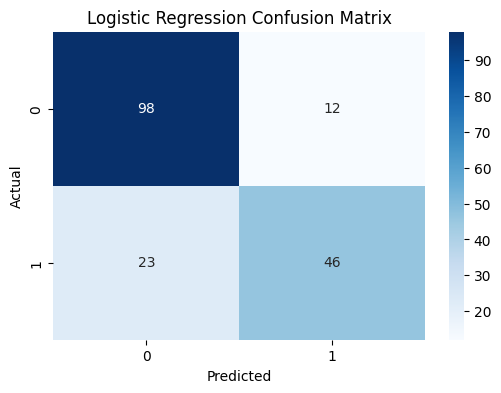

In [53]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Model 2: Random Forest

Random Forest is an ensemble classification algorithm that combines multiple decision trees to make predictions.

It can capture more complex relationships between features than a simple linear model.

In [54]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

print("Random Forest model created.")

Random Forest model created.


In [55]:
random_forest_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [56]:
y_pred_rf = random_forest_model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [57]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(
    y_test,
    random_forest_model.predict_proba(X_test)[:, 1]
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest Results
---------------------
Accuracy : 0.8156424581005587
Precision: 0.8103448275862069
Recall   : 0.6811594202898551
F1 Score : 0.7401574803149606
ROC-AUC  : 0.8335968379446641


In [58]:
print("Random Forest Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



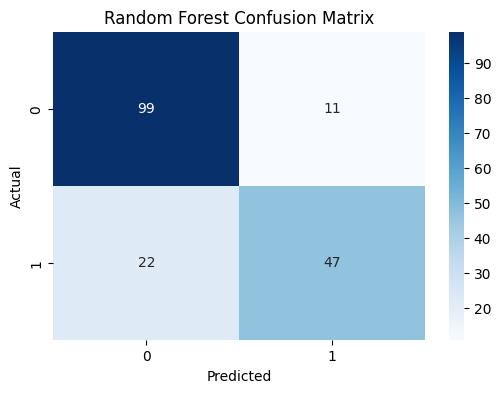

In [59]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
1,Random Forest,0.815642,0.810345,0.681159,0.740157,0.833597


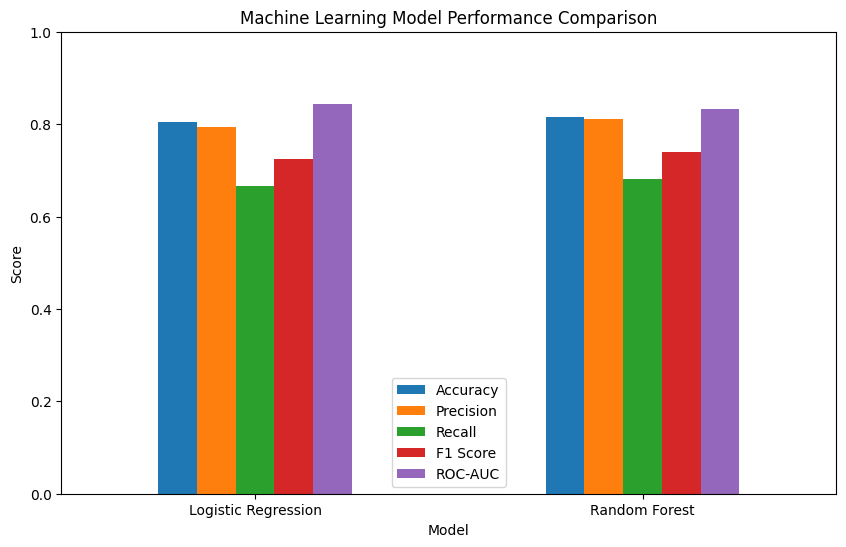

In [61]:
results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

In [62]:
if rf_f1 > logistic_f1:
    better_model = "Random Forest"
elif logistic_f1 > rf_f1:
    better_model = "Logistic Regression"
else:
    better_model = "Both models have the same F1 Score"

print("Model with higher F1 Score:", better_model)

Model with higher F1 Score: Random Forest


In [63]:
if rf_roc_auc > logistic_roc_auc:
    print("Random Forest has the higher ROC-AUC.")
elif logistic_roc_auc > rf_roc_auc:
    print("Logistic Regression has the higher ROC-AUC.")
else:
    print("Both models have the same ROC-AUC.")

Logistic Regression has the higher ROC-AUC.


# Model Comparison and Conclusion

Two machine learning classification models were trained:
Logistic Regression and Random Forest.

The models were evaluated using Accuracy, Precision, Recall,
F1 Score and ROC-AUC.

Based on the test-set evaluation results, the two models showed
different performance across the evaluation metrics.

The model with the stronger overall evaluation results was
identified by comparing the F1 Score and ROC-AUC along with
Accuracy, Precision and Recall.

The results show how different machine learning algorithms can
perform differently on the same dataset.

Based on the evaluation results, Random Forest performed better overall on this test dataset. Its stronger performance can be attributed to its ability to capture nonlinear relationships and interactions between features using multiple decision trees.

# Final Conclusion

In this task, the Titanic dataset was used to train and evaluate two machine learning classification models: Logistic Regression and Random Forest.

The data was prepared by removing unnecessary columns, handling missing values, and converting categorical features into numerical features.

The dataset was divided into training and testing sets.

Both models were trained using the training data and evaluated using Accuracy, Precision, Recall, F1 Score and ROC-AUC.

The performance of the two models was compared using numerical metrics, classification reports, confusion matrices and a performance comparison graph.

This task provided practical experience in data preprocessing, machine learning model training, model evaluation and model comparison.

# Task 3: Model Improvement

## Improving the Random Forest Model

In [ ]:
# Convert text columns into numbers
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Make sure both datasets have the same columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_encoded, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

In [ ]:
best_rf = grid_search.best_estimator_

best_rf.fit(X_train_encoded, y_train)

y_pred_improved = best_rf.predict(X_test_encoded)

print("Improved model created successfully!")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

improved_accuracy = accuracy_score(y_test, y_pred_improved)
improved_precision = precision_score(y_test, y_pred_improved)
improved_recall = recall_score(y_test, y_pred_improved)
improved_f1 = f1_score(y_test, y_pred_improved)

y_prob_improved = best_rf.predict_proba(X_test_encoded)[:, 1]
improved_roc_auc = roc_auc_score(y_test, y_prob_improved)

print("Improved Random Forest Results")
print("Accuracy :", improved_accuracy)
print("Precision:", improved_precision)
print("Recall   :", improved_recall)
print("F1 Score :", improved_f1)
print("ROC-AUC  :", improved_roc_auc)

In [ ]:
comparison = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Task 2 Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ],
    "Task 3 Tuned Random Forest": [
        improved_accuracy,
        improved_precision,
        improved_recall,
        improved_f1,
        improved_roc_auc
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_improved
)

plt.title("Improved Random Forest - Confusion Matrix")
plt.show()

## Conclusion

The Random Forest model was improved using GridSearchCV with 5-fold cross-validation.

The best parameters were:
- n_estimators: 300
- max_depth: None
- min_samples_split: 5

The tuned model was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

The results from Task 2 and Task 3 were compared to understand the effect of hyperparameter tuning on model performance.

The improved model achieved a ROC-AUC score of 0.8426 and a recall of 0.6957 on the test data.